# Question 2: Testing

## Assignment
> Marktplaats has decided on implementing a product feature that we think
will drive the number of Car ads with leads: How would you ideally set up the test
whether this initiative has improved this metric?
> - Why do you choose this method?
> - What are the risks / challenges?
> - Use the dataset attached to examine the test groups:
>   - What is the result of your analysis?
>   - What insights did you gain?

## 1. Business Question and Test Design


### Primary KPI
Share of Car Ads With at Least One Lead.

`has_any_lead = telclicks > 0 OR bids > 0 OR n_asq > 0 OR webclicks > 0`

### Test Design
Use a **randomized A/B test** to answer whether the new product feature increases the share of car ads that receive at least one lead.

Why this method:

- Random assignment is the cleanest way to estimate whether the feature caused a change in lead rate.
- It is better than a before/after comparison, which can be affected by seasonality, buyer demand, or changes in ad supply.

Preferred randomization level: ad-level, assuming the feature affects individual ads and does not strongly change seller behavior across ads. If the feature is seller-side, seller-level randomization may be safer.

### Treatment Assumption
- I assume B is the treatment group and A is control.
- If the assignment were reversed, the product interpretation would reverse too.

### 1.1 Design Risks

Before treating the A/B gap as causal, I would validate:

1. **Assignment integrity**: confirm A/B assignment was random, consistently applied, and close to the planned allocation. Any assignment bug or sample-ratio mismatch could bias the result.
2. **Group comparability**: check whether A and B are balanced on key ad and car attributes such as price, mileage, age, seller type, and placement timing. The dataset shows B differs from A on some dimensions, so part of the lift could reflect mix rather than product impact.
3. **Platform side effects**: monitor whether the feature shifts leads away from control ads or increases low-quality leads, duplicate leads or complaints.

In [1]:
import importlib
import sys
from pathlib import Path

MODULE_DIR = Path("modules").resolve()
if not MODULE_DIR.exists():
    MODULE_DIR = Path("assignments/cars/modules").resolve()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from IPython.display import display

import functions as helpers

helpers = importlib.reload(helpers)
pd = helpers.pd

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 80)
helpers.set_plot_style()


## 2. Data Quality Checks

Before comparing outcomes, I check whether the lead metrics and ad identifiers are reliable enough for analysis:

- Lead metrics are clean enough for analysis: almost no missing values and no negative values.
- Missing lead metrics are minimal: 9 rows have missing values in at least one lead column, so treating missing lead counts as zero has negligible impact.
- Duplicate ad IDs are negligible: 10 rows, checked later as a sensitivity test.


In [2]:
raw_data = helpers.read_ab_test_data(helpers.DATA_PATH)
ab_data, excluded_data = helpers.prepare_ab_data(raw_data)
segmented_data = helpers.add_segments(ab_data)

print(f"Rows: {len(raw_data):,}")


Rows: 183,062


### 2.1 Lead Metric Quality

Checks whether lead-event columns have missing, negative, or extreme values.

In [3]:
display(helpers.style_table(helpers.lead_metric_quality(raw_data)))


,Metric,Missing Rows,Missing %,Negative Rows,Zero Rows,Max Value
0,Tel Clicks,9,0.000,0,"125,624",162
1,Bids,9,0.000,0,"152,145",124
2,Questions,0,0.000,0,"122,577",282
3,Web Clicks,9,0.000,0,"85,122",410


### 2.2 Missing Values

Shows which optional columns have missing values.


In [4]:
display(helpers.style_table(helpers.column_quality_summary(raw_data).query("missing_rows > 0 and column != 'group'"), max_rows=12))


,Column,Dtype,Missing Rows,Missing %,Unique
0,Energy Label,str,"49,384",0.270,7
1,Body Type,str,"17,851",0.098,8
2,Seats,Int64,"11,743",0.064,16
4,Doors,Int64,"5,375",0.029,9
5,Model,str,925,0.005,"2,447"
6,Emissions,Int64,191,0.001,356
7,Bids,Int64,9,0.000,42
8,Tel Clicks,Int64,9,0.000,65
9,Web Clicks,Int64,9,0.000,154
10,Price,Int64,7,0.000,"7,522"


### 2.3 Duplicated Ad IDs

There are 5 duplicated `src_ad_id` values, covering 10 rows. The summary below is enough to show the issue: repeated IDs refer to rows with different car attributes, so they are not full duplicate rows.


In [5]:
display(helpers.style_table(helpers.duplicated_ad_id_differences(raw_data)))

,Ad ID,Rows,Groups Seen,Varying Columns
0,1011548826,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
1,1027581466,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
2,1045227572,2,"A, B","carrosserie, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"
3,1054003502,2,A,"telclicks, carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, model, price"
4,1072325510,2,"A, B","carrosserie, photo_cnt, aantaldeuren, bouwjaar, emissie, energielabel, brand, vermogen, webclicks, model, price, group"


The paired duplicate-ID rows differ on car attributes. Decimal-looking ad IDs are preserved as text, and these duplicates are exact repeated IDs rather than a truncation issue. I keep them in the primary analysis because they are only 10 rows, then test sensitivity later by excluding them.

### 2.4 Undocumented Fields
- The dataset contains some fields not documented in the assignment schema.
- Some undocumented fields are useful for balance and segment checks.
- `l2` is excluded from these checks because its meaning is unclear.

## 3. Group Assignment and Balance Checks

These checks show whether the A/B groups are suitable for causal interpretation before reading the result.

### 3.1 Group Assignment Split

- Raw groups: A, B, and Unassigned.
- 95.3% of rows are assigned to A or B; 4.7% are unassigned and excluded from A-vs-B outcome analysis.
- If the intended design was 50/50, the A/B split should be checked for sample-ratio mismatch before causal interpretation.


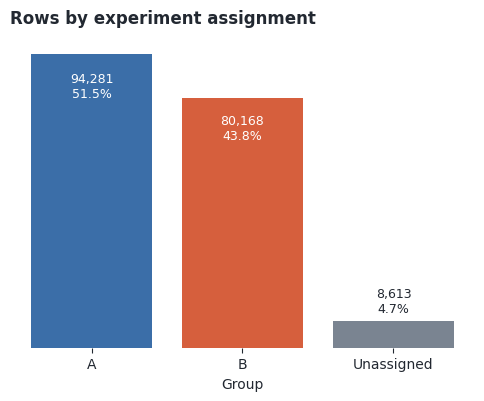

In [6]:
helpers.plot_group_sizes(raw_data)
helpers.plt.show()


The dataset has 174,449 valid A/B rows and 8,613 unassigned rows. If the intended split was 50/50, the A/B allocation should be checked with the experiment owner before interpreting the result causally.


### 3.2 Group Balance

A and B groups differs on key numeric car/ad dimensions, especially price, car age, and mileage.

In [7]:
display(helpers.style_table(helpers.numeric_balance_summary(ab_data)))

group,Dimension,A,B,Diff B-A,% Diff,Std Diff
0,Price,"106,457.104","95,563.256","-10,893.849",-0.102,-0.012
1,Mileage,"140,764.544","149,516.859","8,752.315",0.062,0.094
2,Days Live,27.624,27.646,0.022,0.001,0.001
3,Photos,15.742,15.366,-0.376,-0.024,-0.058
4,Build Year,2007.560,2006.721,-0.839,-0.000,-0.155
5,Doors,4.270,4.220,-0.049,-0.012,-0.050
6,Seats,4.735,4.747,0.012,0.002,0.013
7,Emissions,129.123,129.950,0.827,0.006,0.012
8,Power,85.787,85.420,-0.367,-0.004,-0.009
9,Car Age,8.440,9.279,0.839,0.099,0.155


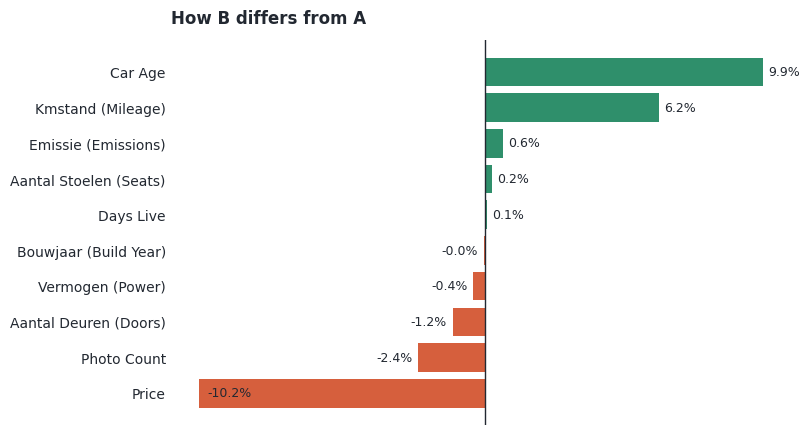

In [8]:
helpers.plot_numeric_balance(ab_data)
helpers.plt.show()


## 4. Primary Results

### 4.1 Result Summary

- Assuming B is the group that received the feature, B has a 74.8% lead rate vs 72.8% for A.
- Difference: +2.0 percentage points; statistically significant (p < 0.001).
- B also has more total leads per ad.
- Caveat: groups are not perfectly balanced, so some of the gap could reflect group mix rather than only the product feature.
- Recommendation: B is directionally positive, but investigate both the assignment imbalance and segment mix imbalance before rollout; also confirm which group received the feature.


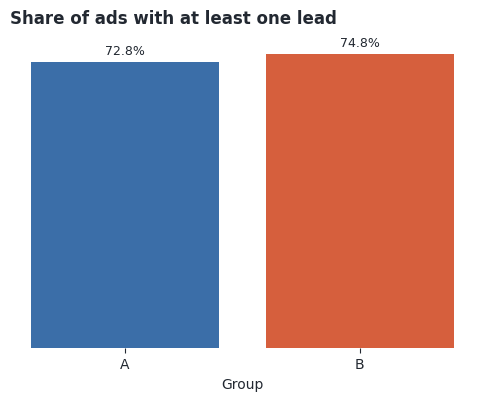

In [9]:
outcomes = helpers.lead_outcome_summary(ab_data)

helpers.plot_lead_rate(outcomes)
helpers.plt.show()


### 4.2 Statistical Inference

- The chart shows the primary KPI directly.
- The table below focuses on lift, confidence interval, and statistical inference.
- I use a **two-sided** two-proportion z-test. Even though the feature is expected to help, a product change could theoretically also hurt leads, so I test for a difference in either direction.
- Given the group assignment and balance concerns above, I interpret statistical significance as evidence that the raw A/B gap is unlikely to be sampling noise, not as causal proof by itself.
- Absolute lift: B minus A, in percentage points.
- Relative lift: absolute lift divided by A lead rate.


In [10]:
display(helpers.lift_summary_table(ab_data).style.hide(axis="index"))


Metric,Value
Absolute lead-rate lift,2.0 pp
95% CI for absolute lift,1.6 to 2.4 pp
Relative lift vs A,2.8%
p-value,<0.001
Significance level,5%


## 5. Post-Inference Checks

### 5.1 Lead Volume Pattern

- B also has higher average lead volume per ad.
- Channel checks show whether the lift is broad or concentrated in one lead type.


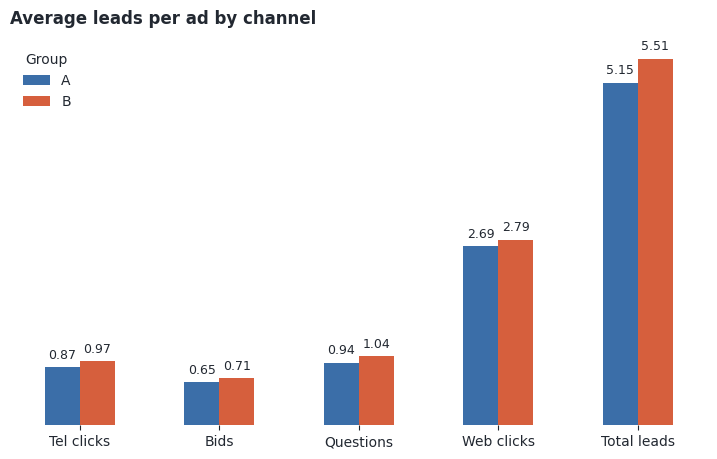

In [11]:
helpers.plot_average_leads_by_channel(outcomes)
helpers.plt.show()


- B is higher on every lead channel and total leads per ad.
- The lift is spread across channels, not driven by one large channel spike.

### 5.2 Duplicate-ID Robustness

Purpose: verify that the duplicate-ID issue found during data readiness does not drive the primary conclusion.


In [12]:
display(helpers.style_table(helpers.duplicated_ad_id_sensitivity(ab_data)))

,Metric,With Dup IDs,Excl Dup IDs
0,Rows,"174,449","174,439"
1,Rows Dropped,0,10
2,% Rows Dropped,0,0.000
3,A Lead Rate,0.728,0.728
4,B Lead Rate,0.748,0.748
5,Abs Lead-Rate Lift,0.020,0.020
6,Relative Lift vs A,0.028,0.028


Excluding duplicated `src_ad_id` rows does not materially change the A/B lead-rate comparison. The result is robust to this specific data-quality issue.

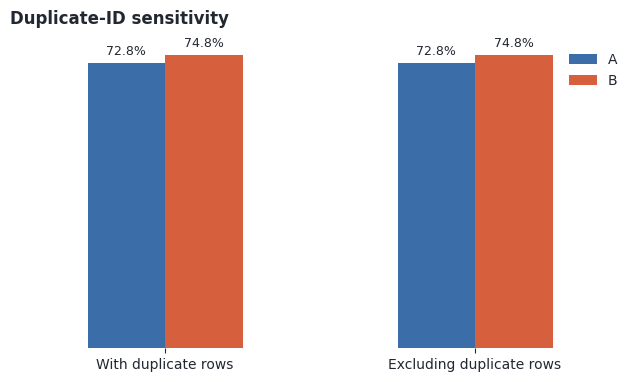

In [13]:
helpers.plot_duplicated_ad_id_sensitivity(ab_data)
helpers.plt.show()


Removing duplicated ad IDs leaves the A and B lead rates essentially unchanged. The duplicate-ID issue is worth documenting, but it does not drive the main result.